# Лабораторная работа №1

In [ ]:
!pip install numpy pandas scikit-learn seaborn matplotlib

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Просматриваем и оцениваем данные

Считываем датасет и выводим его общую информацию


In [10]:
df = pd.read_csv("data/train.csv")
print(df.head())
df.info()

   Student_ID  Age  Gender   Department   CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science 3.5000          7.3000       3.3000   
1        1002   20    Male  Engineering 2.7200          5.5000       7.2000   
2        1003   20    Male      Medical 3.0100          5.4000       2.3000   
3        1004   21    Male  Engineering 3.6300          8.1000       2.0000   
4        1005   19    Male         Arts 3.1400          6.8000       2.6000   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0              3.4000                114             5       False  
1              6.0000                142             2       False  
2              1.8000                137             3       False  
3              4.6000                130             3       False  
4              4.3000                  4             6       False  
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column 

Удаляю столбец с айдишниками, а также смотрю на пропуски, дубликаты и прочие ошибки


In [11]:
print("Размер до очистки:", df.shape)
print("Кол-во пропусков - ")
print(df.isna().sum())
print("Кол-во дубликатов - ", df.duplicated().sum())
print("Кол-во True и False в процентном соотношение от всего дата сета - ")
print(df["Depression"].value_counts(normalize=True))
total_time = df["Sleep_Duration"] + df["Study_Hours"] + df["Social_Media_Hours"]
print("Строк с суммой часов более чем сутки - ", (total_time > 24).sum())
df = df[total_time <= 24].reset_index(drop=True)
df = df.drop(columns=["Student_ID"]).drop_duplicates()
print("Размер после очистки - ", df.shape)


Размер до очистки: (100000, 11)
Кол-во пропусков - 
Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64
Кол-во дубликатов -  0
Кол-во True и False в процентном соотношение от всего дата сета - 
Depression
False   0.8994
True    0.1006
Name: proportion, dtype: float64
Строк с суммой часов более чем сутки -  79
Размер после очистки -  (99921, 10)


Выведем графики числовых значений в датасете

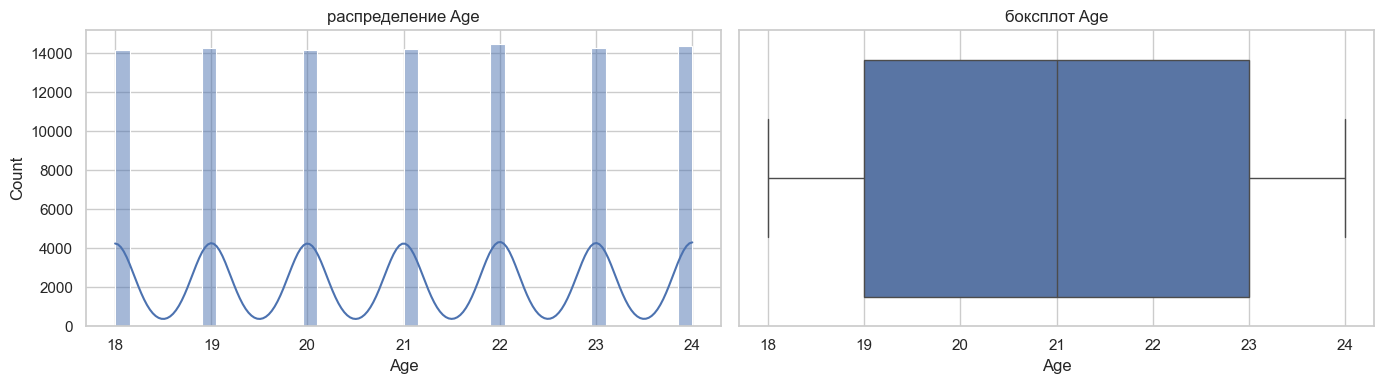

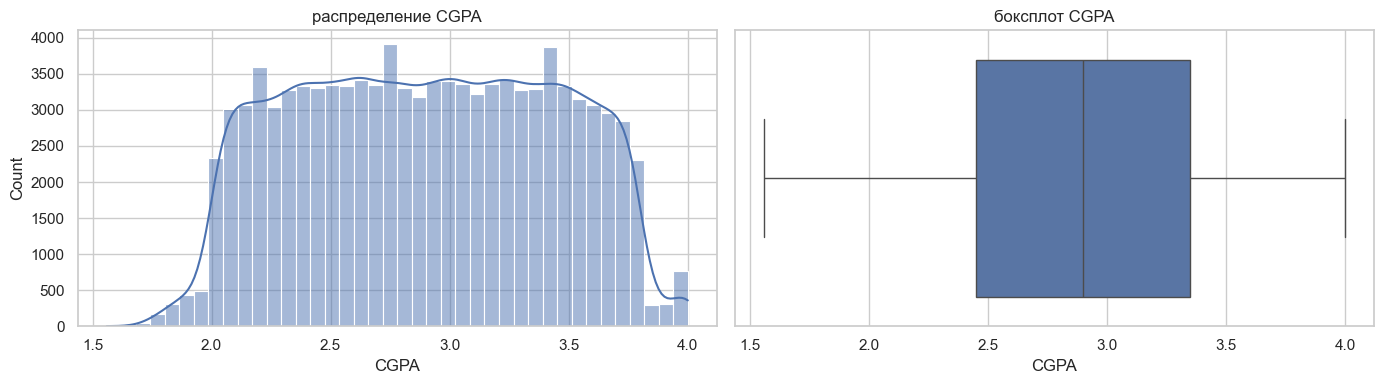

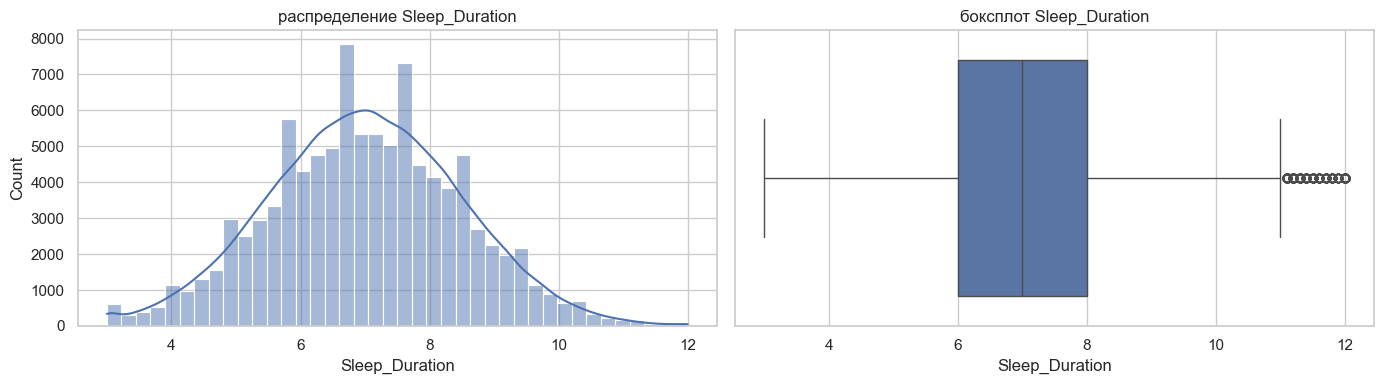

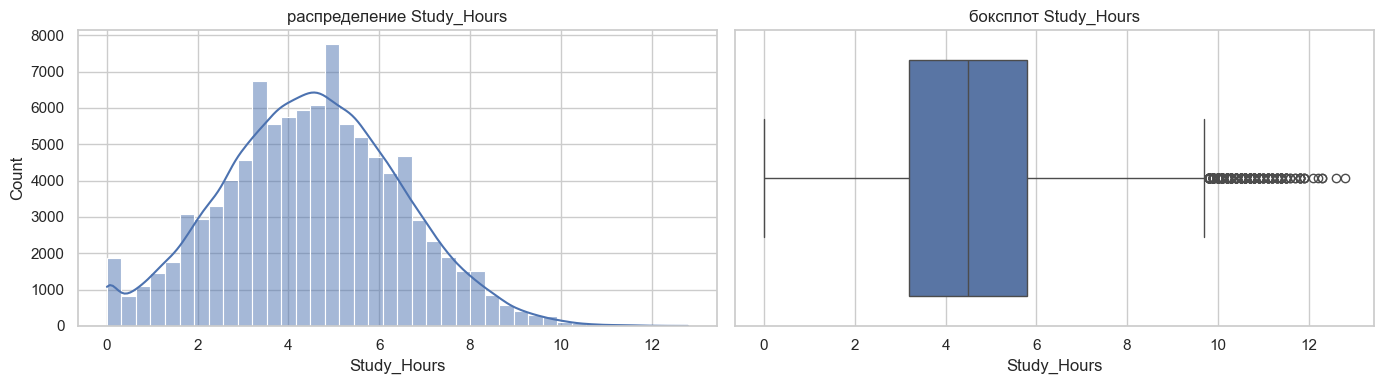

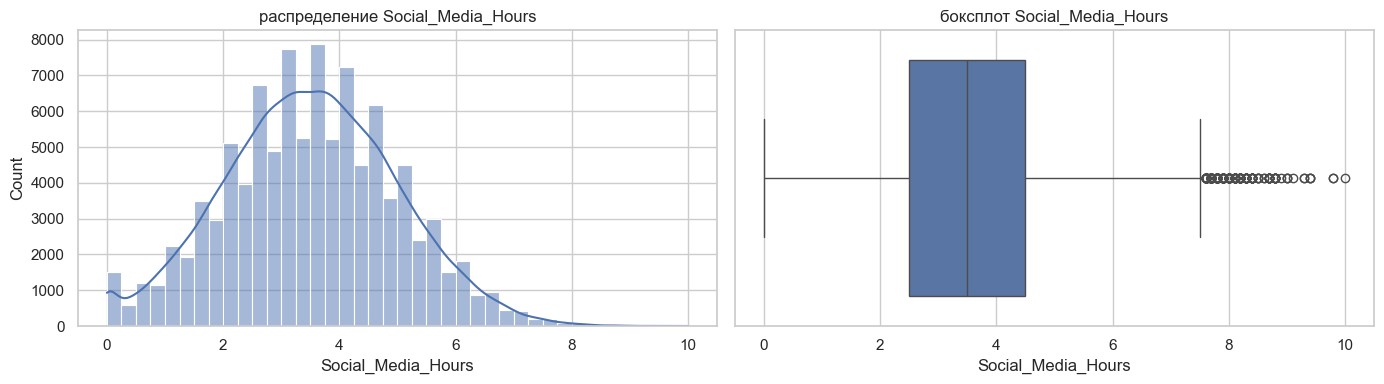

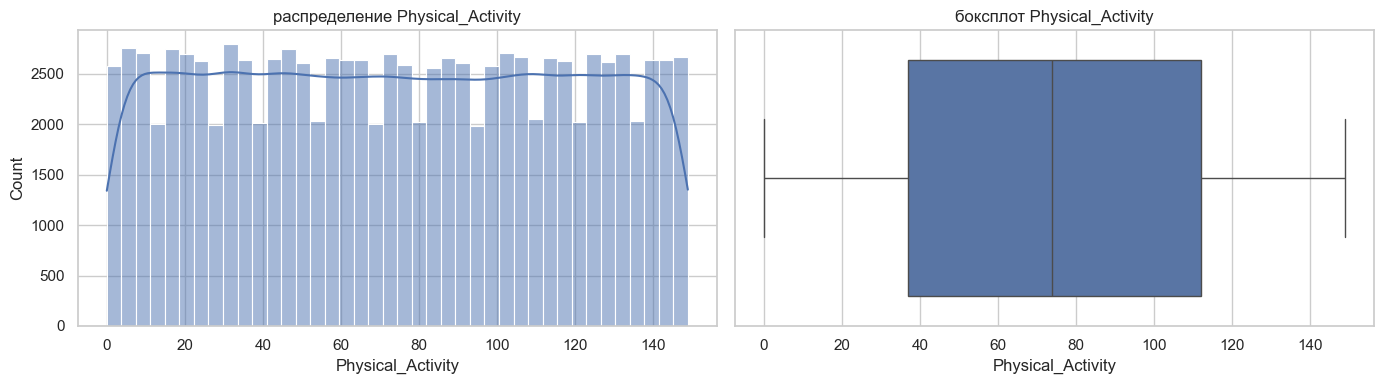

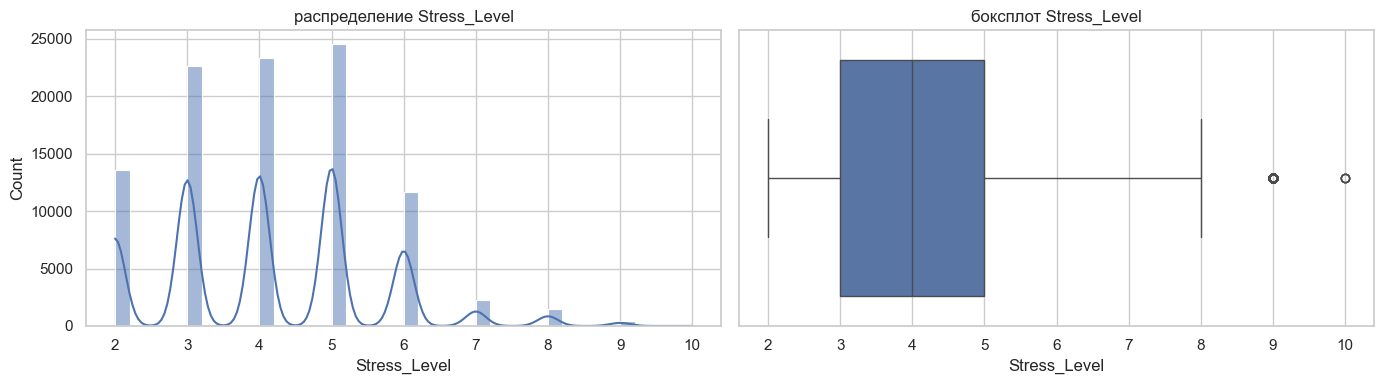

In [18]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

# CGPA - успеваемость

for column in numeric_columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[column], kde=True, bins=40, ax=axes[0])
    axes[0].set_title(f"распределение {column}")
    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f"боксплот {column}")
    plt.tight_layout()
    plt.show()


И графики по категориям


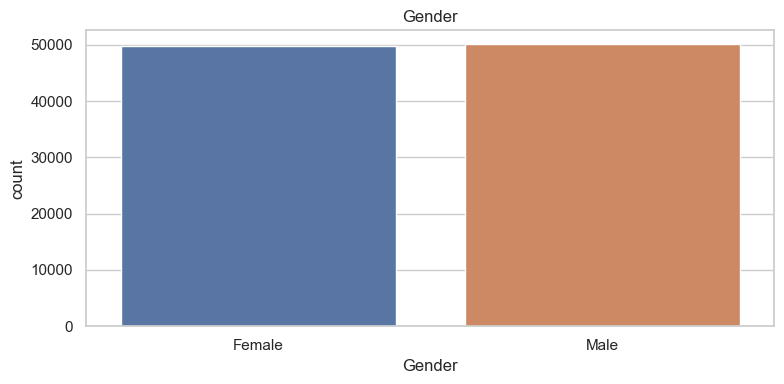

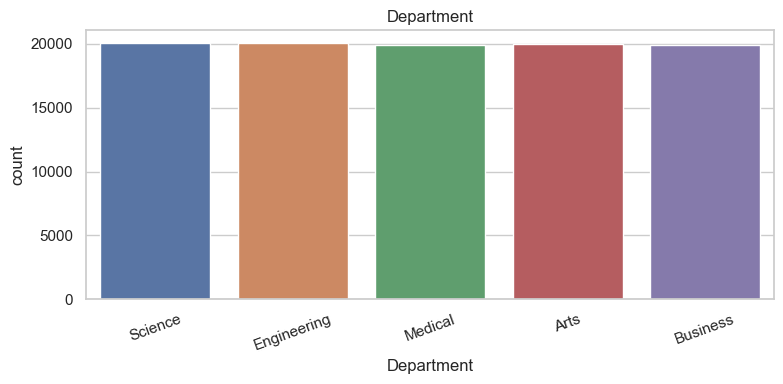

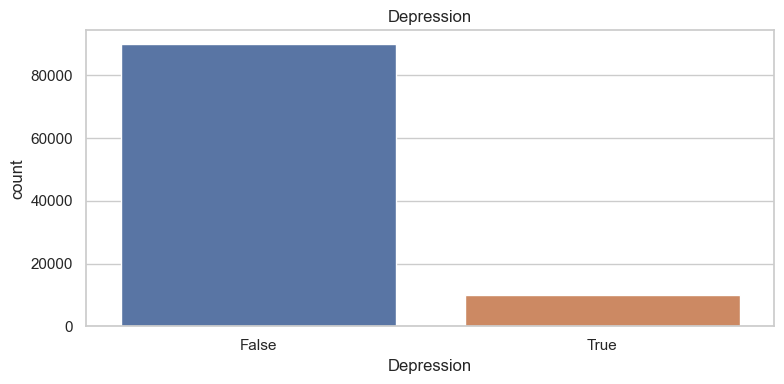

In [16]:
for column in ["Gender", "Department", "Depression"]:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column, hue=column, legend=False)
    plt.title(column)
    if column == "Department":
        plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


Категории вприцнипе сбалансированы

Построим корреляцию для числовых признаков

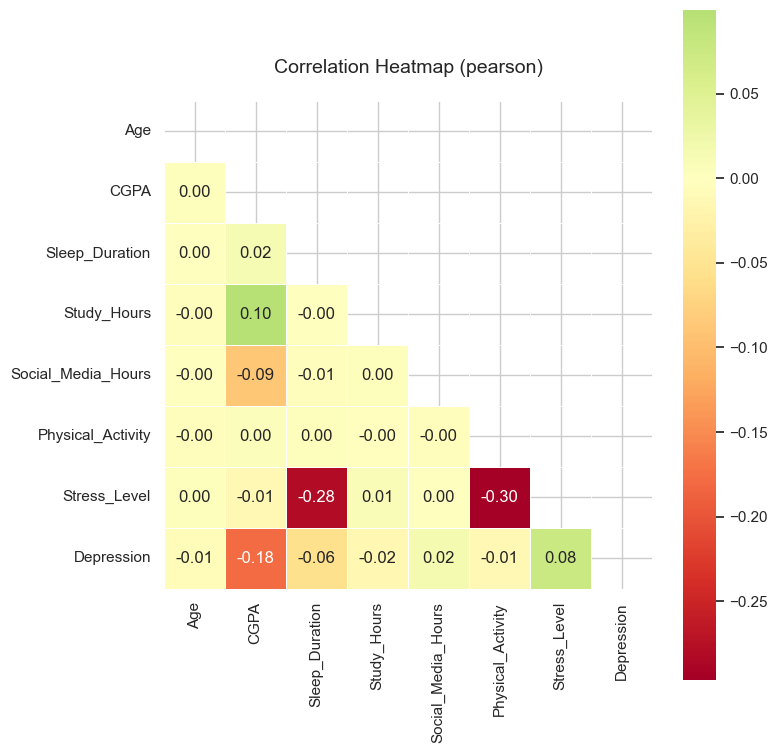

In [20]:
corr_df = df.copy()
corr_df["Depression"] = corr_df["Depression"].astype(int)


def plot_correlation_heatmap(df, target_col=None, method='pearson', threshold=0.7):
    numeric = df.select_dtypes(include=[np.number])
    corr = numeric.corr(method=method)

    plt.figure(figsize=(8, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, square=True, linewidths=0.5)
    plt.title(f'Correlation Heatmap ({method})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(corr_df)


- пропусков и дубликатов нет
- все данные впринципе сбалансированы
- есть люди у кого больше 24 часов в сутках, но в мире сдвгшников это вполне возможно :D
- кол-во имеющих депрессию и не депресивных людей не сбалансировано а имеет соотношение 1 к 9 соотв

## Добавим новые признаки


In [21]:
for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    df[column] = df[column].clip(low, high)

df["Total_Load"] = df["Study_Hours"] + df["Social_Media_Hours"]
df["Free_Time"] = 24 - (df["Sleep_Duration"] + df["Total_Load"])
df["Sleep_Deficit"] = np.clip(7 - df["Sleep_Duration"], 0, None)
df["Screen_to_Study_Ratio"] = df["Social_Media_Hours"] / (df["Study_Hours"] + 0.5)
df["Recovery_Index"] = df["Sleep_Duration"] * (df["Physical_Activity"] + 1) / (df["Stress_Level"] + 1) # коэф восстановления
df["Stress_Load"] = df["Stress_Level"] * df["Total_Load"]

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99921 entries, 0 to 99920
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    99921 non-null  int64  
 1   Gender                 99921 non-null  str    
 2   Department             99921 non-null  str    
 3   CGPA                   99921 non-null  float64
 4   Sleep_Duration         99921 non-null  float64
 5   Study_Hours            99921 non-null  float64
 6   Social_Media_Hours     99921 non-null  float64
 7   Physical_Activity      99921 non-null  int64  
 8   Stress_Level           99921 non-null  int64  
 9   Depression             99921 non-null  bool   
 10  Total_Load             99921 non-null  float64
 11  Free_Time              99921 non-null  float64
 12  Sleep_Deficit          99921 non-null  float64
 13  Screen_to_Study_Ratio  99921 non-null  float64
 14  Recovery_Index         99921 non-null  float64
 15  Stress_Load  

### Feature engineering

Создадим два датасета, базовый и расширенный


In [30]:
dataset_reg_1 = df[
    [
        "Age",
        "Gender",
        "Department",
        "Sleep_Duration",
        "Study_Hours",
        "Social_Media_Hours",
        "Physical_Activity",
        "Stress_Level",
        "CGPA",
    ]
].copy()

dataset_reg_2 = df[
    [
        "Age",
        "Gender",
        "Department",
        "Sleep_Duration",
        "Study_Hours",
        "Social_Media_Hours",
        "Physical_Activity",
        "Stress_Level",
        "Total_Load",
        "Free_Time",
        "Sleep_Deficit",
        "Screen_to_Study_Ratio",
        "Recovery_Index",
        "Stress_Load",
        "CGPA",
    ]
].copy()

dataset_clf_1 = df[
    [
        "Sleep_Duration",
        "Study_Hours",
        "Social_Media_Hours",
        "Physical_Activity",
        "Stress_Level",
        "Total_Load",
        "Free_Time",
        "Sleep_Deficit",
        "Screen_to_Study_Ratio",
        "Recovery_Index",
        "Stress_Load",
        "Depression",
    ]
].copy()

dataset_clf_2 = df[
    [
        "Age",
        "Gender",
        "Department",
        "Sleep_Duration",
        "Study_Hours",
        "Social_Media_Hours",
        "Physical_Activity",
        "Stress_Level",
        "Total_Load",
        "Free_Time",
        "Sleep_Deficit",
        "Screen_to_Study_Ratio",
        "Recovery_Index",
        "Stress_Load",
        "Depression",
    ]
].copy()


## Разделение данных

Напишем функцию, которая будет делить данные на train, validation и test, а также применять кодирование и масштабирование.


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample

RANDOM_STATE = 42

def resample_dataset(dataframe, target_column):
    """
    Балансирует датасет с помощью upsampling (тоесть растягиваем True до размера False)
    копирует случйно обьекты меньшего класса и вставляет, увеличивая размер класса
    """
    data_true = dataframe[dataframe[target_column] == 1]
    data_false = dataframe[dataframe[target_column] == 0]

    data_true_up = resample(
        data_true,
        replace=True,
        n_samples=len(data_false),
        random_state=RANDOM_STATE,
    )

    return pd.concat([data_false, data_true_up]).sample(frac=1, random_state=RANDOM_STATE)

In [26]:
def split_dataset(dataset, target_column, need_resample=False):
    """
    Делит датасет на train / validation / test, выполняет (опционально) балансировку
    и применяет масштабирование и one-hot encoding
    """
    y = dataset[target_column]
    X = dataset.drop(columns=[target_column])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=y if target_column == "Depression" else None,
    )

    X_test, X_validate, y_test, y_validate = train_test_split(
        X_test,
        y_test,
        test_size=0.5,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=y_test if target_column == "Depression" else None,
    )

    if need_resample:
        train_df = pd.concat([X_train, y_train], axis=1)
        train_df = resample_dataset(train_df, target_column)
        X_train = train_df.drop(columns=[target_column])
        y_train = train_df[target_column]

    num_columns = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cat_columns = X_train.select_dtypes(include=["object", "category", "str"]).columns.tolist()

    preprocessor = ColumnTransformer(
        [
            ("num", StandardScaler(), num_columns),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_columns),
        ]
    )

    X_train_scaled = preprocessor.fit_transform(X_train)
    X_validate_scaled = preprocessor.transform(X_validate)
    X_test_scaled = preprocessor.transform(X_test)

    features = preprocessor.get_feature_names_out()

    return (
        X_train_scaled,
        X_validate_scaled,
        X_test_scaled,
        y_train,
        y_validate,
        y_test,
        features,
    )

## Обучение модели для задачи регрессии

Обучим `LinearRegression` и посмотрим на метрики


In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import learning_curve


def evaluate_regression(y_true, y_pred, dataset_name="Dataset"):
    """Вычисляет и выводит основные метрики регрессии"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f"Метрики для {dataset_name}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}")
    print(f"  MAPE: {mape:.4f}")

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}


def create_coef_bar(model, features, title):
    """Строит барплот коэффициентов модели"""
    coefs = model.coef_
    if hasattr(coefs, "ndim") and coefs.ndim > 1:
        coefs = coefs[0]
    coefs = pd.Series(coefs, index=features).sort_values(key=np.abs, ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    coefs.sort_values().plot(kind="barh")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def create_learning_curve_plot(model, X, y, score, title):
    """Строит графики обучения модели"""
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring=score,
        train_sizes=np.linspace(0.1, 1.0, 5),
    )

    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
    plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

Базовый датасет:
Метрики для Train
  MAE:  0.4550
  RMSE: 0.5279
  R2:   0.0178
  MAPE: 0.1657
Метрики для Validation
  MAE:  0.4516
  RMSE: 0.5248
  R2:   0.0159
  MAPE: 0.1644
Метрики для Test
  MAE:  0.4548
  RMSE: 0.5275
  R2:   0.0207
  MAPE: 0.1648


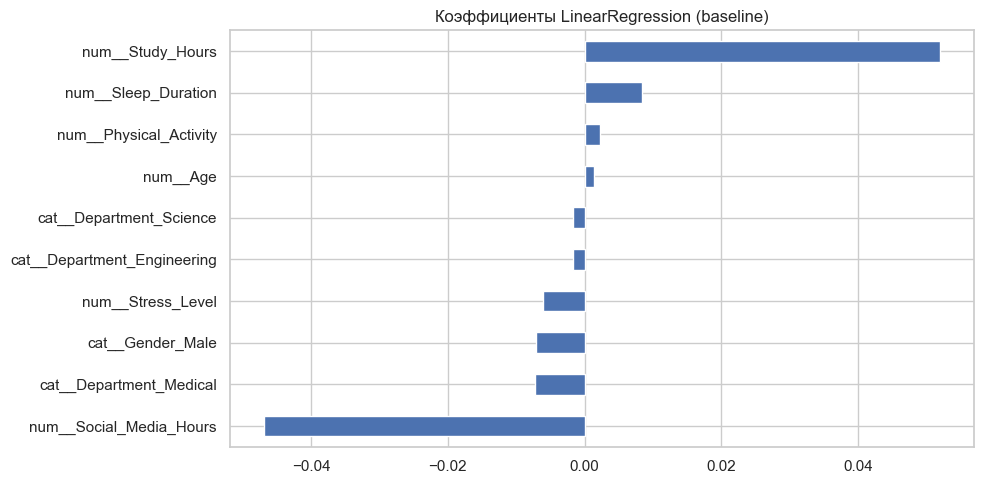

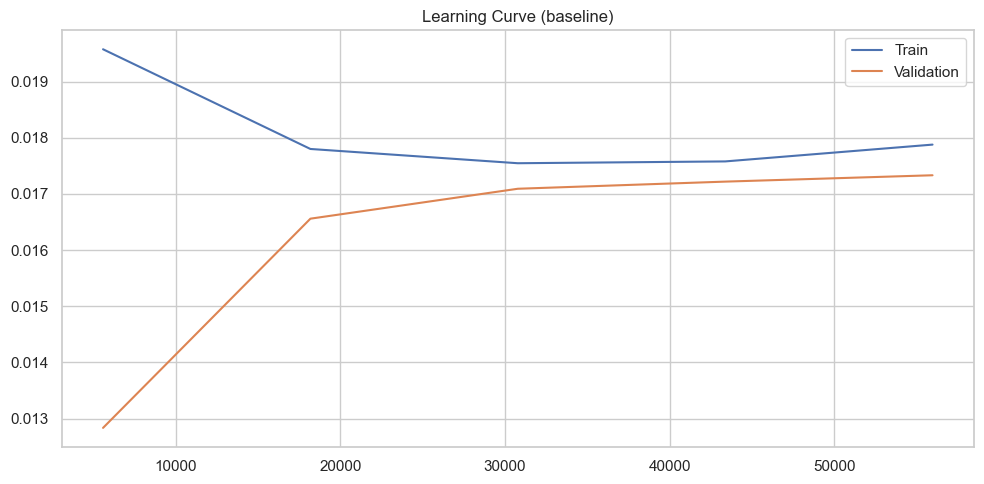

In [32]:
from sklearn.linear_model import LinearRegression

print("Базовый датасет:")
X_train, X_validate, X_test, y_train, y_validate, y_test, features = split_dataset(dataset_reg_1, "CGPA")
reg_model_1 = LinearRegression()
reg_model_1.fit(X_train, y_train)

reg_1_train = reg_model_1.predict(X_train)
reg_1_val = reg_model_1.predict(X_validate)
reg_1_test = reg_model_1.predict(X_test)

reg_1_train_metrics = evaluate_regression(y_train, reg_1_train, "Train")
reg_1_val_metrics = evaluate_regression(y_validate, reg_1_val, "Validation")
reg_1_test_metrics = evaluate_regression(y_test, reg_1_test, "Test")

create_coef_bar(reg_model_1, features, "Коэффициенты LinearRegression (baseline)")
create_learning_curve_plot(reg_model_1, X_train, y_train, "r2", "Learning Curve (baseline)")


Расширенный датасет:
Метрики для Train
  MAE:  0.4546
  RMSE: 0.5274
  R2:   0.0197
  MAPE: 0.1656
Метрики для Validation
  MAE:  0.4512
  RMSE: 0.5245
  R2:   0.0171
  MAPE: 0.1643
Метрики для Test
  MAE:  0.4542
  RMSE: 0.5267
  R2:   0.0239
  MAPE: 0.1646


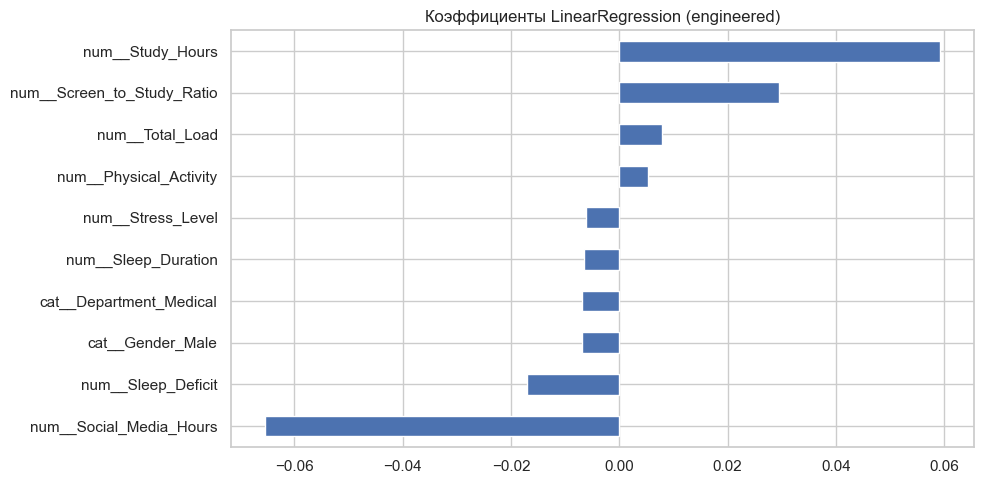

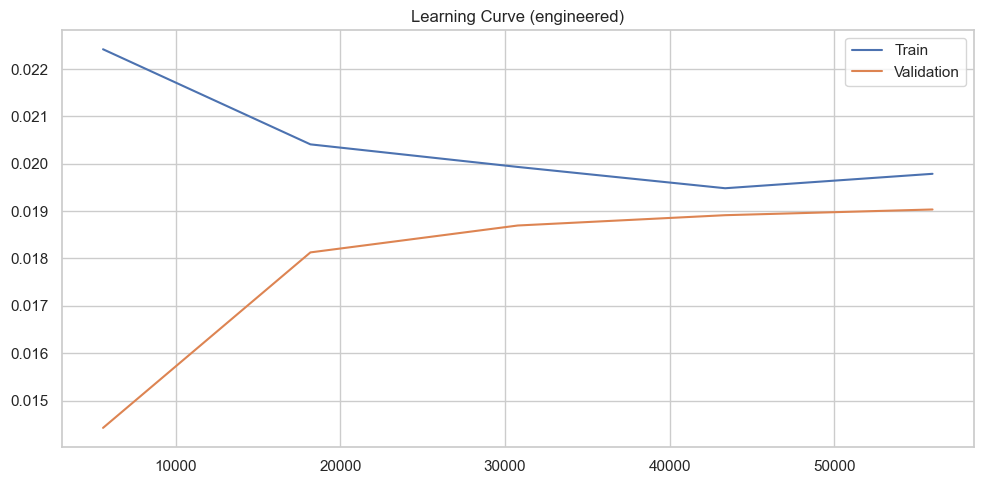

In [33]:
print("Расширенный датасет:")
X_train, X_validate, X_test, y_train, y_validate, y_test, features = split_dataset(dataset_reg_2, "CGPA")
reg_model_2 = LinearRegression()
reg_model_2.fit(X_train, y_train)

reg_2_train = reg_model_2.predict(X_train)
reg_2_val = reg_model_2.predict(X_validate)
reg_2_test = reg_model_2.predict(X_test)

reg_2_train_metrics = evaluate_regression(y_train, reg_2_train, "Train")
reg_2_val_metrics = evaluate_regression(y_validate, reg_2_val, "Validation")
reg_2_test_metrics = evaluate_regression(y_test, reg_2_test, "Test")

create_coef_bar(reg_model_2, features, "Коэффициенты LinearRegression (engineered)")
create_learning_curve_plot(reg_model_2, X_train, y_train, "r2", "Learning Curve (engineered)")


По регрессии расширенный датасет получился немного лучше. Но `R²` всё равно невысокий, значит `CGPA` по этим признакам предсказывается не очень точно.


## Обучение модели для задачи классификации

Обучим `LogisticRegression` и сравним несколько значений числа итераций.


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)


def evaluate_classification(y_true, y_pred, y_score, dataset_name="Dataset"):
    """Считает основные метрики классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_score)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC-ROC": auc_roc,
    }


def create_roc_curve(y_true, y_score, title):
    """Строит ROC-кривую"""
    plt.figure(figsize=(8, 5))
    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def create_confusion_matrix(y_true, y_pred, title):
    """Строит матрицу ошибок"""
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [38]:
clf_rows = []
clf_models = {}

from sklearn.linear_model import LogisticRegression

for dataset_name, dataset in [("lifestyle_only", dataset_clf_1), ("lifestyle_plus_context", dataset_clf_2)]:
    X_train, X_validate, X_test, y_train, y_validate, y_test, features = split_dataset(
        dataset,
        "Depression",
        need_resample=True,
    )

    for epochs in [100, 300, 700]:
        model = LogisticRegression(random_state=RANDOM_STATE, max_iter=epochs)
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        validate_pred = model.predict(X_validate)
        test_pred = model.predict(X_test)

        train_score = model.predict_proba(X_train)[:, 1]
        validate_score = model.predict_proba(X_validate)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]

        train_metrics = evaluate_classification(y_train, train_pred, train_score, "Train")
        validate_metrics = evaluate_classification(y_validate, validate_pred, validate_score, "Validation")
        test_metrics = evaluate_classification(y_test, test_pred, test_score, "Test")

        clf_rows.append(
            {
                "dataset": dataset_name,
                "epochs": epochs,
                "train_f1": train_metrics["F1"],
                "validation_f1": validate_metrics["F1"],
                "test_f1": test_metrics["F1"],
                "validation_auc": validate_metrics["AUC-ROC"],
                "test_auc": test_metrics["AUC-ROC"],
            }
        )

        clf_models[(dataset_name, epochs)] = {
            "model": model,
            "features": features,
            "X_train": X_train,
            "y_train": y_train,
            "X_validate": X_validate,
            "y_validate": y_validate,
            "X_test": X_test,
            "y_test": y_test,
            "train_metrics": train_metrics,
            "validate_metrics": validate_metrics,
            "test_metrics": test_metrics,
            "test_pred": test_pred,
            "test_score": test_score,
        }

clf_result = pd.DataFrame(clf_rows).sort_values(["validation_f1", "test_auc"], ascending=False)
display(clf_result)

best_row = clf_result.iloc[0]
best_clf = clf_models[(best_row["dataset"], best_row["epochs"])]
print("Лучшая модель:", best_row["dataset"], "epochs =", int(best_row["epochs"]))


,dataset,epochs,train_f1,validation_f1,test_f1,validation_auc,test_auc
3,lifestyle_plus_context,100,0.4773,0.1887,0.1876,0.5615,0.5535
4,lifestyle_plus_context,300,0.4773,0.1887,0.1876,0.5615,0.5535
5,lifestyle_plus_context,700,0.4773,0.1887,0.1876,0.5615,0.5535
0,lifestyle_only,100,0.4736,0.1880,0.1881,0.5604,0.5524
1,lifestyle_only,300,0.4736,0.1880,0.1881,0.5604,0.5524
2,lifestyle_only,700,0.4736,0.1880,0.1881,0.5604,0.5524


Лучшая модель: lifestyle_plus_context epochs = 100


In [39]:
print("Метрики лучшей модели:")
for name, metrics in [
    ("Train", best_clf["train_metrics"]),
    ("Validation", best_clf["validate_metrics"]),
    ("Test", best_clf["test_metrics"]),
]:
    print(name)
    for key, value in metrics.items():
        print(f"  {key}: {value:.4f}")


Метрики лучшей модели:
Train
  Accuracy: 0.5427
  Precision: 0.5570
  Recall: 0.4176
  F1: 0.4773
  AUC-ROC: 0.5630
Validation
  Accuracy: 0.6455
  Precision: 0.1226
  Recall: 0.4095
  F1: 0.1887
  AUC-ROC: 0.5615
Test
  Accuracy: 0.6445
  Precision: 0.1218
  Recall: 0.4078
  F1: 0.1876
  AUC-ROC: 0.5535


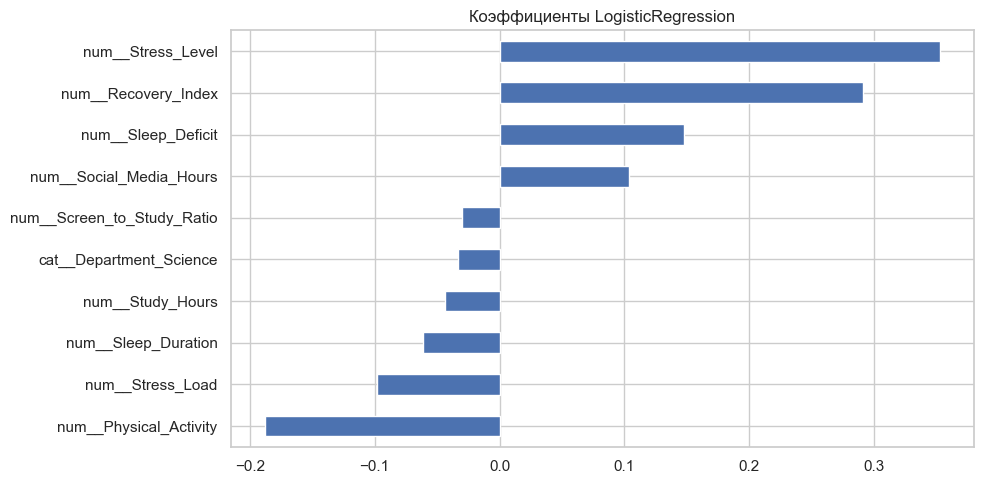

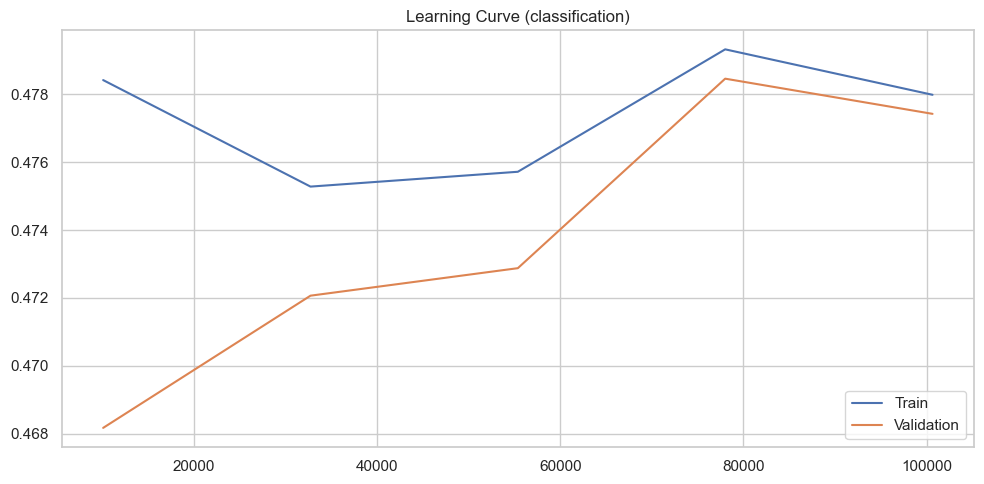

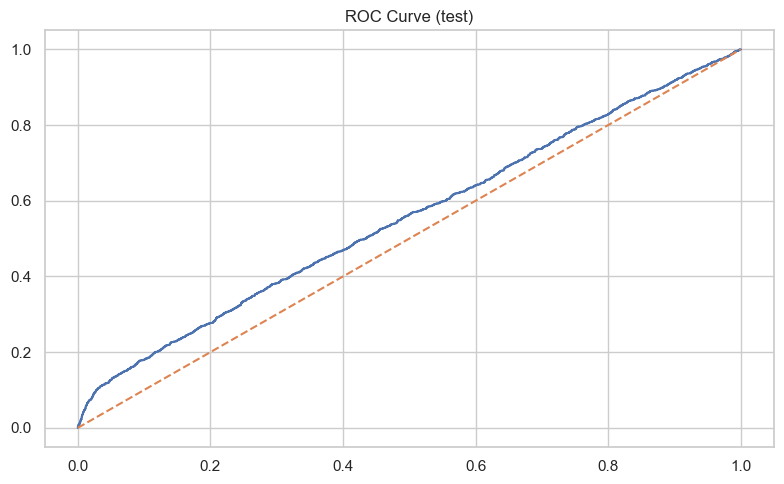

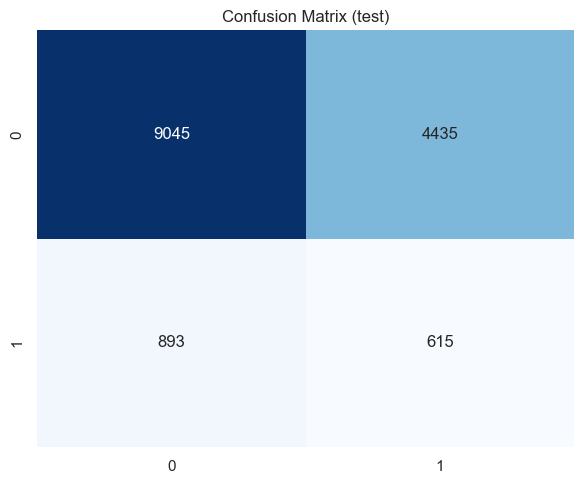

In [40]:
create_coef_bar(best_clf["model"], best_clf["features"], "Коэффициенты LogisticRegression")
create_learning_curve_plot(best_clf["model"], best_clf["X_train"], best_clf["y_train"], "f1", "Learning Curve (classification)")
create_roc_curve(best_clf["y_test"], best_clf["test_score"], "ROC Curve (test)")
create_confusion_matrix(best_clf["y_test"], best_clf["test_pred"], "Confusion Matrix (test)")


Метрики на train, validation и test отличаются не очень сильно, а learning curve не показывает сильного расхождения. Значит, заметного переобучения здесь нет

## Вывод

После очистки данных, обработки выбросов, кодирования признаков и масштабирования удалось построить модели для обеих задач. Для регрессии немного лучше сработал расширенный датасет, а для классификации лучше показал себя набор `lifestyle_plus_context`.

Метрики получились не очень высокими.